In [1]:
import numpy as np
import matplotlib.pylab as plt

import torch
import torch.nn as nn
from torch.optim import Adam

from simulation import RodentMotionModel, SquareArena, SimulationController
from networks import ContinuousTimeRNN
from regularization import LinearLambdaScheduler, AdaptiveLambdaScheduler
from regularization import (
    mean_squared_error,
    l2_weight_regularization,
    firing_rate_regularization,
)
from utils import (
    plot_square,
    plot_simulation,
    generate_dataset,
    compute_spatial_bounds,
    compute_unit_activity_map,
    compute_spatial_bin_edges_from_bounds,
    plot_activity_map
)

In [2]:
seed = 42
theta_sigma = 0.1
p_move = 0.1
v_max = 0.2
arena_size = 1.6
max_tries = 100

In [3]:
rodent = RodentMotionModel(seed, theta_sigma, p_move, v_max)
arena = SquareArena(arena_size)

controller = SimulationController(rodent, arena, max_tries)

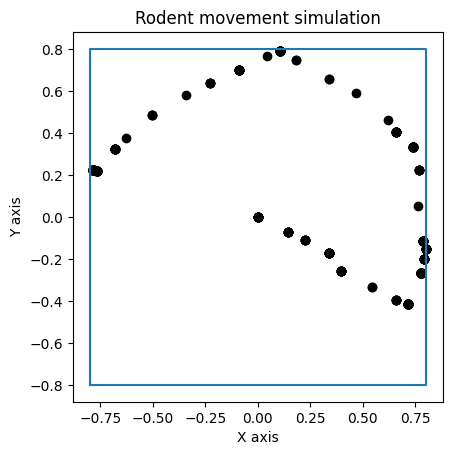

In [6]:
simulation_data = controller.generate(500)

plot_simulation(simulation_data, arena)

In [12]:
num_inputs = 2
num_outputs = 2
num_units = 100

noise_std = 0.01
time_constant = 0.1
time_step = time_constant / 10

In [13]:
model = ContinuousTimeRNN(
    num_inputs,
    num_outputs,
    num_units,
    noise_std,
    time_step,
    time_constant
)

In [14]:
device = "cuda" if torch.cuda.is_available() else "cpu"

num_steps = 500

num_epochs = 2000
batches_per_epoch = 1
batch_size = 500
learning_rate = 1e-03

In [15]:
optimizer = Adam(model.parameters(), lr=learning_rate)

weight_l2_lambda_scheduler = LinearLambdaScheduler(
    1, 0.0001, num_epochs
)
firing_rate_lambda_scheduler = AdaptiveLambdaScheduler(
    0.1, 0.3, num_epochs
)

In [16]:
torch.manual_seed(seed)

losses = []

model.to(device)
model.train()

for epoch in range(1, num_epochs + 1):
    inputs, targets = generate_dataset(
        controller, batch_size, num_steps, num_inputs, num_outputs
    )

    inputs = inputs.to(device)
    targets = targets.to(device)

    activities, predictions = model(inputs)

    in_weights = model.input_weights.weight
    out_weights = model.output_weights.weight


    prediction_loss = mean_squared_error(targets, predictions)
    w_regularization = l2_weight_regularization(in_weights, out_weights)
    l_w = weight_l2_lambda_scheduler.lambda_at(epoch)
            
    fr_regularization = firing_rate_regularization(activities)
    l_fr = firing_rate_lambda_scheduler.lambda_at(
        epoch, prediction_loss, fr_regularization
    )

    loss = (
        prediction_loss + l_w * w_regularization + l_fr * fr_regularization
    )
    
    optimizer.zero_grad()
    loss.backward()

    nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    losses.append(prediction_loss.item())
    print(f"Epoch: {epoch} | Loss: {prediction_loss.item():.6f}")

Epoch: 1 | Loss: 0.364076
Epoch: 2 | Loss: 0.345794
Epoch: 3 | Loss: 0.329859
Epoch: 4 | Loss: 0.306843
Epoch: 5 | Loss: 0.301076
Epoch: 6 | Loss: 0.296113
Epoch: 7 | Loss: 0.289377
Epoch: 8 | Loss: 0.297302
Epoch: 9 | Loss: 0.290585
Epoch: 10 | Loss: 0.296701
Epoch: 11 | Loss: 0.284798
Epoch: 12 | Loss: 0.278286
Epoch: 13 | Loss: 0.273801
Epoch: 14 | Loss: 0.272913
Epoch: 15 | Loss: 0.261528
Epoch: 16 | Loss: 0.262463
Epoch: 17 | Loss: 0.253965
Epoch: 18 | Loss: 0.254662
Epoch: 19 | Loss: 0.261473
Epoch: 20 | Loss: 0.260926
Epoch: 21 | Loss: 0.250260
Epoch: 22 | Loss: 0.257687
Epoch: 23 | Loss: 0.248603
Epoch: 24 | Loss: 0.249026
Epoch: 25 | Loss: 0.246696
Epoch: 26 | Loss: 0.250670
Epoch: 27 | Loss: 0.245336
Epoch: 28 | Loss: 0.236925
Epoch: 29 | Loss: 0.238732
Epoch: 30 | Loss: 0.229966
Epoch: 31 | Loss: 0.244504
Epoch: 32 | Loss: 0.219139
Epoch: 33 | Loss: 0.226628
Epoch: 34 | Loss: 0.230986
Epoch: 35 | Loss: 0.229191
Epoch: 36 | Loss: 0.224023
Epoch: 37 | Loss: 0.218403
Epoch: 38 

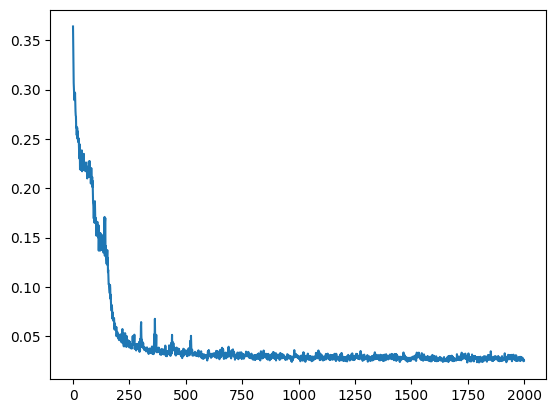

In [17]:
plt.plot(losses);

In [18]:
test_num_steps = 500
test_batches = 10
test_batch_size = 256

accumulated_mse = 0.0

model.to(device)
model.eval()

with torch.inference_mode():
    for _ in range(test_batches):
        inputs, targets = generate_dataset(
            controller, test_batch_size, test_num_steps, num_inputs, num_outputs
        )

        inputs = inputs.to(device)
        targets = targets.to(device)

        activities, predictions = model(inputs)
        accumulated_mse += mean_squared_error(targets, predictions).item()

avearge_mse = accumulated_mse / test_batches
print(f"Test MSE: {avearge_mse:.6f}")

Test MSE: 0.026386


idx: 243


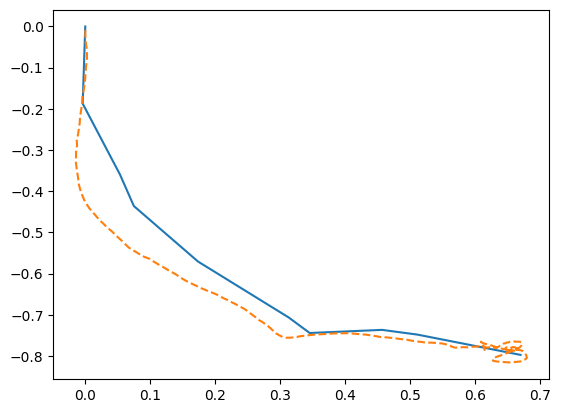

In [44]:
idx = np.random.randint(low=0, high=255)
print(f"idx: {idx}")

plt.plot(
    targets[idx, :, 0].detach().to("cpu"),
    targets[idx, :, 1].detach().to("cpu")
)
plt.plot(
    predictions[idx, :, 0].detach().to("cpu"),
    predictions[idx, :, 1].detach().to("cpu"), "--"
)

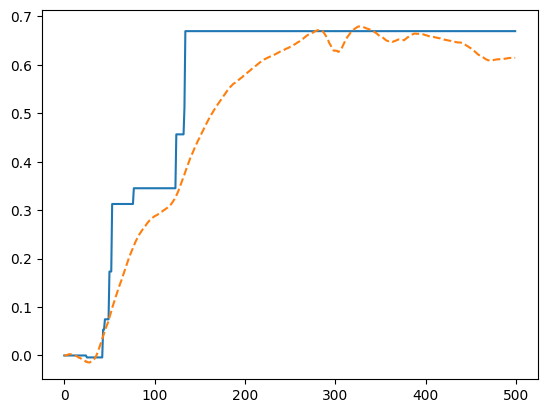

In [45]:
# idx = np.random.randint(low=0, high=255)
# print(f"idx: {idx}")

plt.plot(targets[idx, :, 0].detach().to("cpu"))
plt.plot(predictions[idx, :, 0].detach().to("cpu"), "--")

In [57]:
rodent = RodentMotionModel(seed, theta_sigma=1, p_move=1, v_max=v_max)
controller = SimulationController(rodent, arena, max_tries)

inputs, targets = generate_dataset(controller, 1,  int(100000 * arena_size), 2, 2)
inputs = inputs.to(device)

activities, predictions = model(inputs)

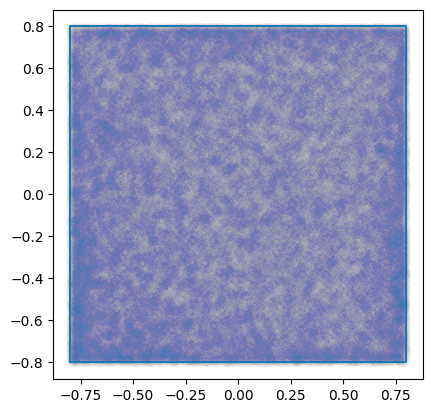

In [58]:
t = targets.to("cpu").detach().numpy().reshape(-1, 2)
a = activities.to("cpu").detach().numpy().reshape(-1, 100)

plot_square(size=arena.size, center=arena.center())
plt.gca().set_aspect("equal", adjustable="box")
plt.scatter(x = t[:, 0], y = t[:, 1], alpha=0.005);

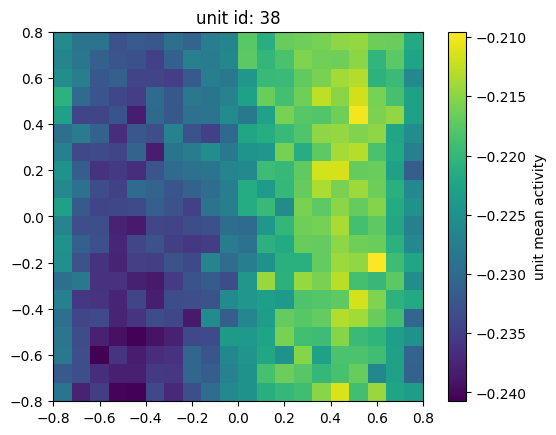

In [93]:
arena_size = arena.size
arena_center = arena.center()

positions = targets.squeeze().to("cpu").detach().numpy().reshape(-1, 2)

random_unit_id = np.random.randint(low=0, high=99)
unit_activity = activities.reshape(-1, 100)[:, random_unit_id].to("cpu").detach().numpy()

num_bins = 20

spatial_bounds = compute_spatial_bounds(
    arena_center, arena_size
)
activity_map, occupancy_map = compute_unit_activity_map(
    positions, unit_activity, spatial_bounds, num_bins
)
x_edges, y_edges = compute_spatial_bin_edges_from_bounds(
    spatial_bounds, num_bins
)

plot_activity_map(activity_map, x_edges, y_edges, title=f"unit id: {random_unit_id}")

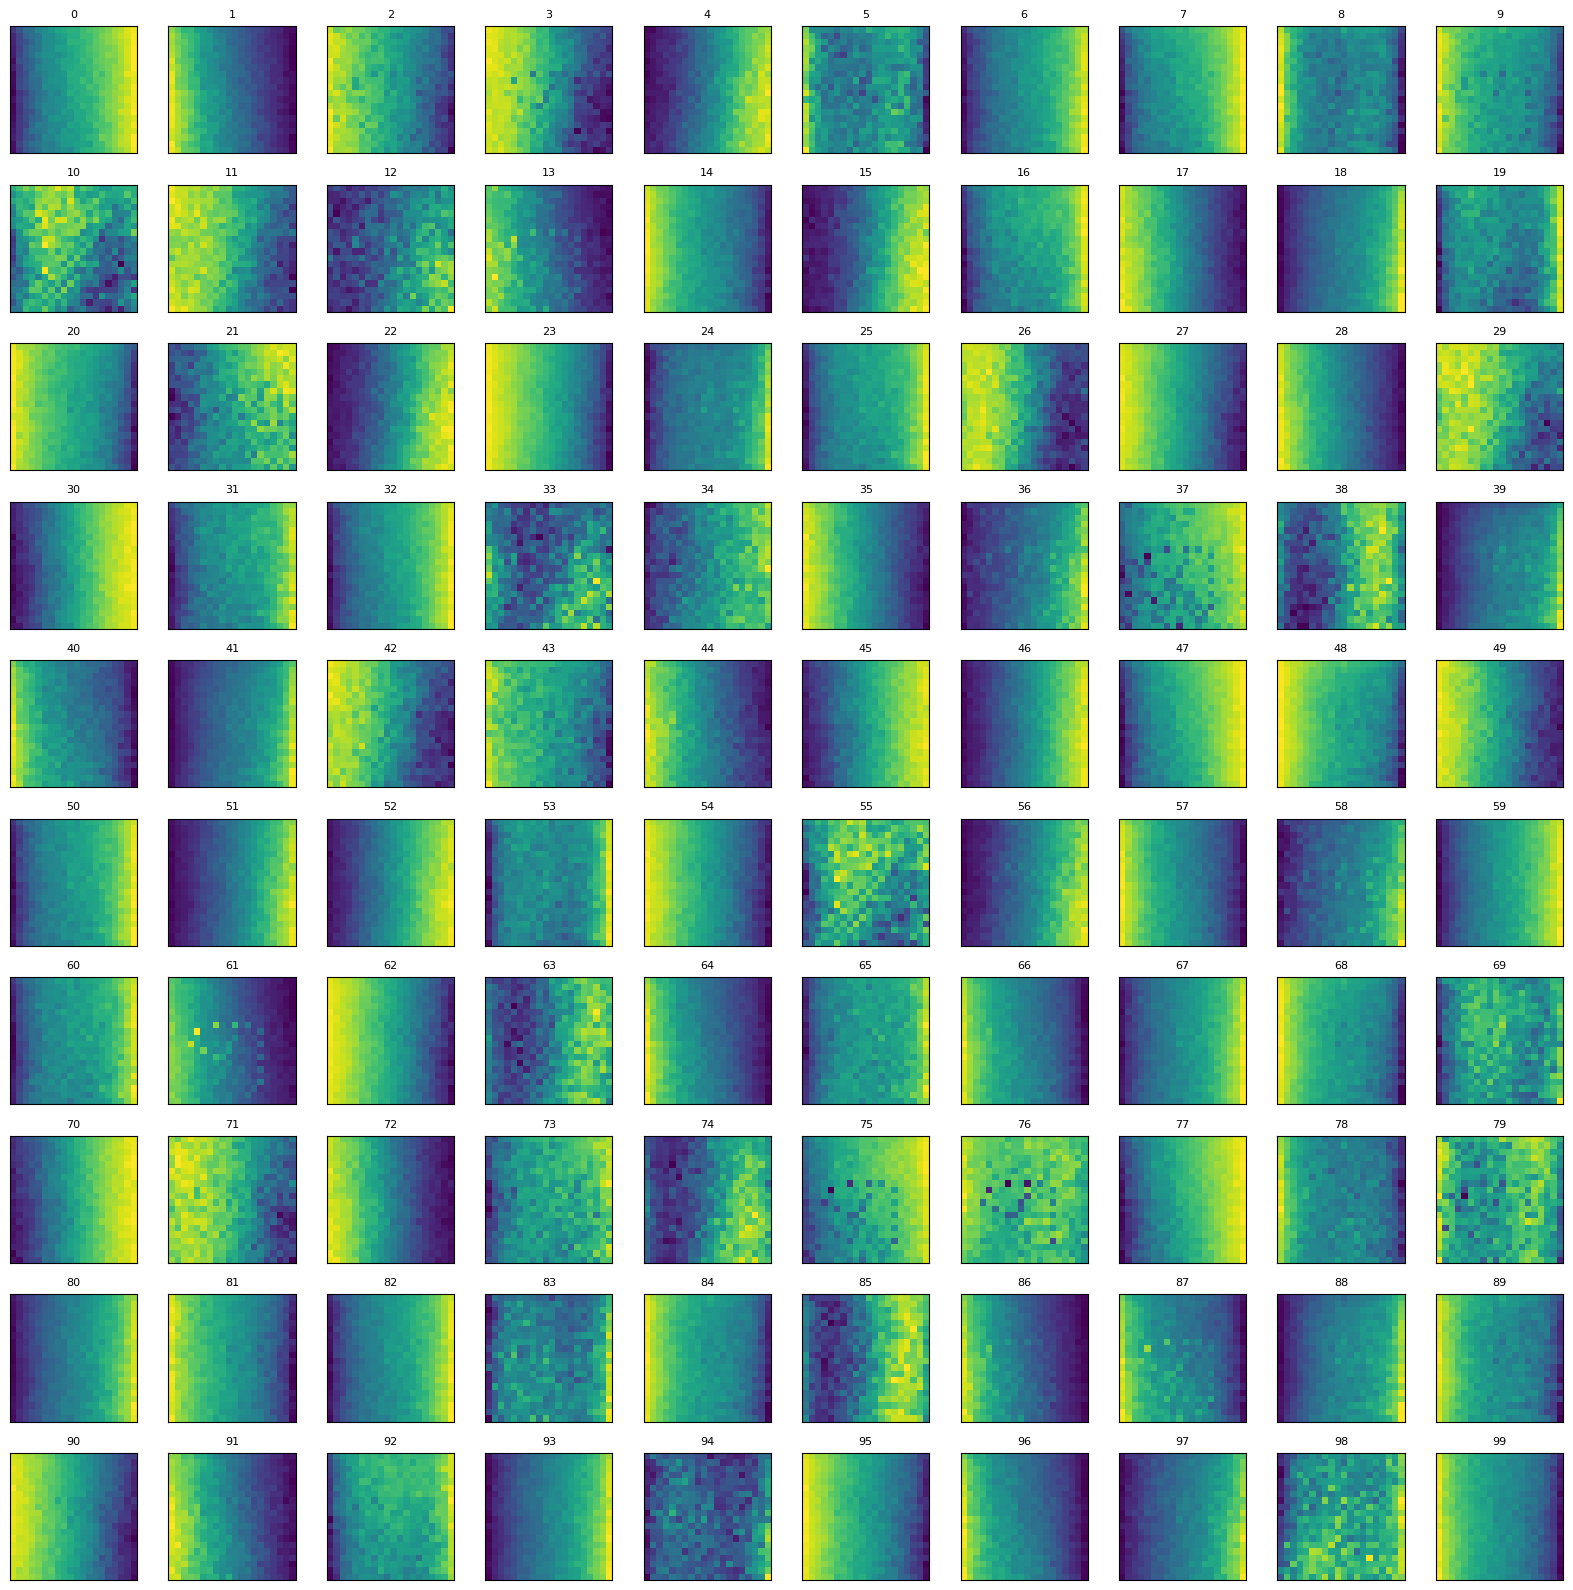

In [ ]:
num_bins = 20

spatial_bounds = compute_spatial_bounds(arena_center, arena_size)
x_edges, y_edges = compute_spatial_bin_edges_from_bounds(spatial_bounds, num_bins)

activities_np = activities.reshape(-1, 100).to("cpu").detach().numpy()

all_maps = []
vmin = np.inf
vmax = -np.inf

for unit_id in range(activities_np.shape[1]):
    unit_activity = activities_np[:, unit_id]
    unit_activity = np.asarray(unit_activity).ravel()

    activity_map, occupancy_map = compute_unit_activity_map(
        positions, unit_activity, spatial_bounds, num_bins
    )

    all_maps.append(activity_map)
    vmin = min(vmin, np.nanmin(activity_map))
    vmax = max(vmax, np.nanmax(activity_map))

fig, axes = plt.subplots(10, 10, figsize=(16, 16), sharex=True, sharey=True)
axes = axes.ravel()

mappable = None
for unit_id, ax in enumerate(axes):
    m = ax.pcolormesh(
        x_edges, y_edges, all_maps[unit_id],
        shading="flat",
    )
    mappable = m
    ax.set_aspect("equal", adjustable="box")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(str(unit_id), fontsize=8)


plt.tight_layout()
plt.show()